In [3]:
import torch
from torch import nn    
from torchsummary import summary
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
torch.manual_seed(33)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(33)
device = ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
class ScaledTanh(nn.Module):
    def forward(self, x):
        return 1.7159 * torch.tanh((2/3) * x)
    

In [5]:
import torch.nn as nn

class LeNet5(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            ScaledTanh(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(6, 16, kernel_size=5),
            ScaledTanh(),
            nn.AvgPool2d(2, 2),

            nn.Conv2d(16, 120, kernel_size=5),
            ScaledTanh(),

            nn.Flatten(),
            nn.Linear(120, 84),
            ScaledTanh(),
        )
        self.classifier = nn.Linear(84, output_features)

    def forward(self, x):
        x = self.network(x)
        x = self.classifier(x)
        return x

In [24]:
model = LeNet5(input_features=1, output_features=10)
model.to(device)

LeNet5(
  (network): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ScaledTanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ScaledTanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): ScaledTanh()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=120, out_features=84, bias=True)
    (10): ScaledTanh()
  )
  (classifier): Linear(in_features=84, out_features=10, bias=True)
)

In [9]:
class LenetNormalize:
    def __call__(self, x):
        return (1.175 + 0.1) * (x / 255.0) - 0.1

transform = transforms.Compose([
    transforms.Resize((32, 32)),   # LeNet 5 expects 32x32 as per paper
    transforms.ToImage(),          # ToTensor() is deprecated
    transforms.ToDtype(torch.float32),
    LenetNormalize(), #paper keeps pixel values in range [-0.1, 1.175] to speed up convergence
])

In [ ]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [26]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

Text(0.5, 1.0, 'Label: 5')

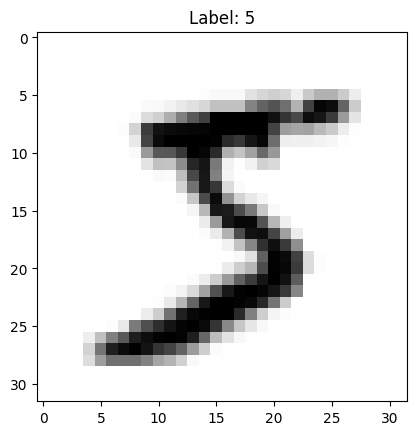

In [27]:
plt.imshow(train_dataset[0][0].squeeze(), cmap="gray")
plt.title(f"Label: {train_dataset[0][1]}")

In [28]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
num_epochs = 20

In [30]:
for epoch in range(num_epochs):

        model.train()

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)
            outputs = model(X)
            optimizer.zero_grad()
            loss = loss_fn(outputs, y)
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.11611995846033096
Epoch 2, Loss: 0.043493758887052536
Epoch 3, Loss: 0.04417640343308449
Epoch 4, Loss: 0.009190070442855358
Epoch 5, Loss: 0.001039372757077217
Epoch 6, Loss: 0.11606280505657196
Epoch 7, Loss: 0.0004057129262946546
Epoch 8, Loss: 0.00024204912187997252
Epoch 9, Loss: 0.01238488219678402
Epoch 10, Loss: 0.0001409627147950232


In [34]:
model.eval()
correct = 0
total = 0
with torch.inference_mode():
    for X, y in test_loader:

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.65%


In [ ]:
torch.save(model.state_dict(), "lenet5_notebook.pth")

In [13]:
model = LeNet5(input_features=1, output_features=10)
model.load_state_dict(torch.load("results/checkpoints/lenet5.pth"))
model.to(device)


LeNet5(
  (network): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ScaledTanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ScaledTanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): ScaledTanh()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=120, out_features=84, bias=True)
    (10): ScaledTanh()
  )
  (classifier): Linear(in_features=84, out_features=10, bias=True)
)

In [14]:
import numpy as np
from PIL import Image, ImageOps
import torch
def predict(image):

    image = image["composite"]

    img = Image.fromarray(image.astype("uint8"))
    # Convert RGBA → grayscale
    img = img.convert("L")
    # Invert: Sketchpad has white background + dark strokes,
    # but MNIST has black background + white strokes
    img = ImageOps.invert(img)
    img = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.inference_mode():
        outputs = model(img)
        pred = torch.argmax(outputs, dim=1).item()

    return f"Predicted Digit: {pred}"

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict,
    inputs=gr.Sketchpad(),
    outputs="text",
    title="LeNet-5 MNIST Digit Recognizer",
    description="Draw a digit and the LeNet-5 model will (try to) predict it."
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "C:\Users\yugpa\AppData\Roaming\Python\Python312\site-packages\gradio\queueing.py", line 626, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\yugpa\AppData\Roaming\Python\Python312\site-packages\gradio\route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\yugpa\AppData\Roaming\Python\Python312\site-packages\gradio\blocks.py", line 2220, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\yugpa\AppData\Roaming\Python\Python312\site-packages\gradio\blocks.py", line 1731, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\yugpa\AppData\Roaming\Python\Python312\site-packages\anyio\to_thr